# Сжатие картинок с помощью SVD разложения
В этом задании нужно сделать сжатие изображения, сжатие с потерями. Для этого мы используем SVD разложение.

Примерный порядок действий:
1) Найти любую картинку,
2) Прочитать её с помощью библиотеки PIL
3) Преобразовать в numpy массив
4) Применить SVD к матрице - обязательно прочитайте справку по этой функции `np.linalg.svd`

**Примечание**: Цветная картинка представляет собой трёхканальное изображение RBG, поэтому напрямую SVD разложение применить не получится. Либо вы преобразуете изображение в одноканальное (градации серого), усредняя все три канала. Либо делаете SVD для всех трёх каналов в отдельности.

5) Далее оставляете небольшое количество сингулярных значений - 1, 2, 10, 30, 100. И выводите результат в виде получившейся картинки - чем больше сингулярных чисел, тем ближе приближённая матрица к исходной.

6) Сравните количество байт, необходимых для хранения исходной картинки и сжатой версии.

Ниже представлены основные функции и библиотеки, которые вам понадобятся.

Задание оформляете в виде блокнота jupyter. Особо понравившиеся картинки можно сохранить отдельно на диск, но мне удобнее чтобы они присутствовали в самом jupyter блокноте.

Исходное изображение: (131, 175, 3)
k=1: Коэффициент сжатия = 18.67x
k=2: Коэффициент сжатия = 9.33x
k=10: Коэффициент сжатия = 1.87x
k=30: Коэффициент сжатия = 0.62x
k=100: Коэффициент сжатия = 0.19x


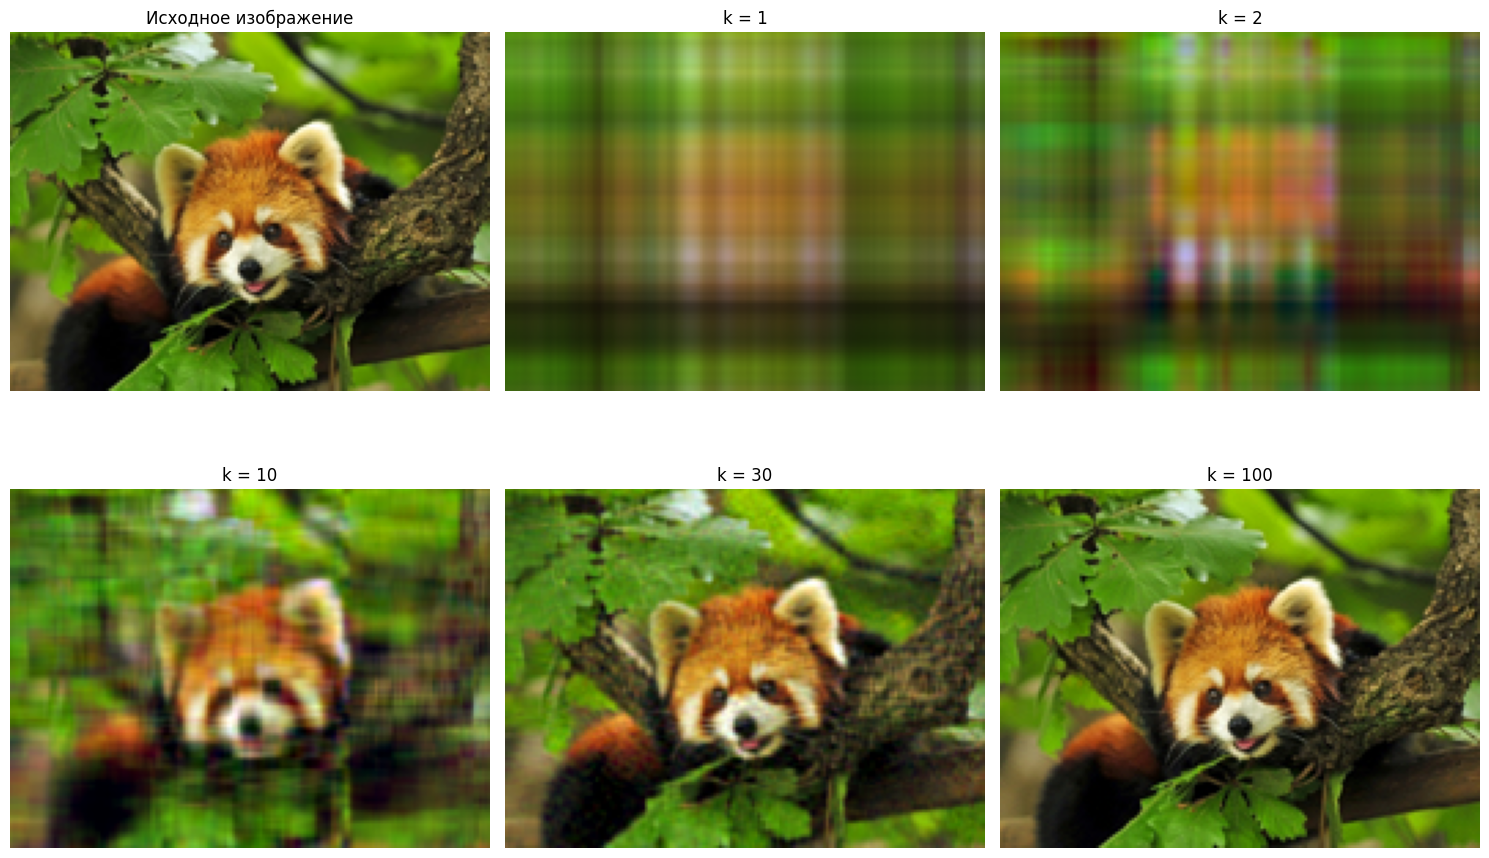


Размер исходного изображения: 67.16 КБ


In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. Загружаем изображение
img = Image.open('panda.jpg')
w, h = img.size
img = img.resize((w//4, h//4))  # Уменьшаем размер для ускорения обработки

# 2. Преобразуем в numpy массив
img_array = np.array(img)

# Проверяем, является ли изображение цветным
if len(img_array.shape) == 3 and img_array.shape[2] == 3:
    # Изображение цветное (RGB) - будем обрабатывать каждый канал отдельно
    print(f"Исходное изображение: {img_array.shape}")
    
    # 3. Применяем SVD к каждому каналу
    channels = ['R', 'G', 'B']
    compressed_images = {}
    
    # Параметры сжатия
    k_values = [1, 2, 10, 30, 100]
    
    # Создаем фигуру для отображения
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Отображаем исходное изображение
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title('Исходное изображение')
    axes[0, 0].axis('off')
    
    # Считаем размер исходного изображения
    original_size = img_array.nbytes / 1024  # в КБ
    
    for idx, k in enumerate(k_values):
        row = (idx + 1) // 3
        col = (idx + 1) % 3
        
        # Восстанавливаем изображение с k сингулярными значениями
        compressed_channels = []
        for channel in range(3):
            # Берем один канал
            channel_matrix = img_array[:, :, channel].astype(float)
            
            # Применяем SVD
            U, S, Vt = np.linalg.svd(channel_matrix, full_matrices=False)
            
            # Оставляем только k сингулярных значений
            U_k = U[:, :k]
            S_k = np.diag(S[:k])
            Vt_k = Vt[:k, :]
            
            # Восстанавливаем матрицу
            compressed_channel = np.dot(U_k, np.dot(S_k, Vt_k))
            
            # Ограничиваем значения
            compressed_channel = np.clip(compressed_channel, 0, 255)
            compressed_channels.append(compressed_channel)
        
        # Объединяем каналы
        compressed_img = np.stack(compressed_channels, axis=2).astype(np.uint8)
        
        # Сохраняем для отображения
        compressed_images[k] = compressed_img
        
        # Отображаем сжатое изображение
        axes[row, col].imshow(compressed_img)
        axes[row, col].set_title(f'k = {k}')
        axes[row, col].axis('off')
        
        # Считаем размер сжатого изображения
        # Для хранения нужно: U_k (h×k), S_k (k), Vt_k (k×w) для каждого канала
        h, w = img_array.shape[:2]
        compressed_size = 3 * (h * k + k + k * w) * 4 / 1024  # в КБ (float32 = 4 байта)
        
        print(f"k={k}: Коэффициент сжатия = {original_size/compressed_size:.2f}x")
    
    plt.tight_layout()
    plt.show()
    
    # 4. Сравниваем размеры
    print(f"\nРазмер исходного изображения: {original_size:.2f} КБ")
    
    # Сохраняем одно из сжатых изображений для примера
    Image.fromarray(compressed_images[30]).save('compressed_panda_k30.jpg')
    
else:
    # Изображение в оттенках серого
    print("Обработка изображения в оттенках серого")
    gray_array = np.array(img.convert('L')) if len(img_array.shape) == 3 else img_array
    
    # Применяем SVD
    U, S, Vt = np.linalg.svd(gray_array.astype(float), full_matrices=False)
    
    # Создаем фигуру для отображения
    k_values = [1, 2, 10, 30, 100]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(gray_array, cmap='gray')
    axes[0, 0].set_title('Исходное изображение')
    axes[0, 0].axis('off')
    
    original_size = gray_array.nbytes / 1024
    
    for idx, k in enumerate(k_values):
        row = (idx + 1) // 3
        col = (idx + 1) % 3
        
        # Восстанавливаем с k сингулярными значениями
        U_k = U[:, :k]
        S_k = np.diag(S[:k])
        Vt_k = Vt[:k, :]
        
        compressed_img = np.dot(U_k, np.dot(S_k, Vt_k))
        compressed_img = np.clip(compressed_img, 0, 255).astype(np.uint8)
        
        axes[row, col].imshow(compressed_img, cmap='gray')
        axes[row, col].set_title(f'k = {k}')
        axes[row, col].axis('off')
        
        # Расчет размера
        h, w = gray_array.shape
        compressed_size = (h * k + k + k * w) * 4 / 1024
        
        print(f"k={k}: Коэффициент сжатия = {original_size/compressed_size:.2f}x")
    
    plt.tight_layout()
    plt.show()
    print(f"\nРазмер исходного изображения: {original_size:.2f} КБ")